# 📊 EDA on Retail Sales Data
**OASIS INFOBYTE — Data Analytics Internship (OIBSIP)**
**Track:** Data Analytics | **Level 1 · Task 1**

**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Folder for GitHub:** `OIBSIP/DataAnalytics-L1-EDARetailSales/`


## 1. Setup — Install & Import Libraries

In [1]:
# Run this once (in Colab, keep the ! - in local Jupyter with a venv, run in terminal instead)
!pip install pandas numpy matplotlib seaborn --quiet


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Dataset

**Dataset used:** *Retail Sales Dataset* (a widely-used Kaggle dataset matching this task's requirements: transaction-level retail data with customer demographics).

**How to get it:**
1. Go to Kaggle and search **"Retail Sales Dataset"** (author: `mohammadtalib786`), or use this direct search: https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset
2. Download `retail_sales_dataset.csv`.
3. Upload it to Colab (left sidebar → Files → Upload), **or** place it in the same folder as this notebook if running locally.
4. Make sure the filename matches `DATA_PATH` below (or change `DATA_PATH` to match your file).

**Expected columns:** `Transaction ID, Date, Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, Total Amount`

> 💡 If your dataset has slightly different column names (e.g. `Order Date` instead of `Date`), don't worry — the code below **auto-detects** the right columns. If auto-detection fails for a column, it will tell you exactly which one to fix.


In [3]:
DATA_PATH = "retail_sales_dataset.csv"   # <-- change this if your file has a different name/path

df_raw = pd.read_csv(DATA_PATH)
print("Loaded dataset with shape:", df_raw.shape)
df_raw.head()


Loaded dataset with shape: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 3. Auto-Detect Columns
This makes the notebook work even if your downloaded CSV has slightly different column names than expected.


In [4]:
def find_col(df, candidates):
    """Find the actual column name in df matching one of the candidate names (case-insensitive, partial match)."""
    cols_lower = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    for cand in candidates:
        for cl, orig in cols_lower.items():
            if cand.lower() in cl:
                return orig
    return None

col_map = {
    'date':        find_col(df_raw, ['Date', 'Order Date', 'Purchase Date']),
    'customer_id': find_col(df_raw, ['Customer ID', 'CustomerID']),
    'gender':      find_col(df_raw, ['Gender', 'Sex']),
    'age':         find_col(df_raw, ['Age']),
    'category':    find_col(df_raw, ['Product Category', 'Category']),
    'product':     find_col(df_raw, ['Product Name', 'Product']),
    'quantity':    find_col(df_raw, ['Quantity', 'Qty']),
    'price':       find_col(df_raw, ['Price per Unit', 'Unit Price', 'Price']),
    'amount':      find_col(df_raw, ['Total Amount', 'Sales', 'Total', 'Revenue']),
}

print("Detected column mapping:")
for k, v in col_map.items():
    status = "OK" if v else "NOT FOUND"
    print(f"  {k:12s} -> {v}   [{status}]")

# 'date' and 'amount' are essential — everything else degrades gracefully if missing
missing_required = [k for k in ('date', 'amount') if col_map[k] is None]
if missing_required:
    raise ValueError(
        f"Required column(s) not detected: {missing_required}. "
        f"Open your CSV, check the exact column names, and edit col_map above manually, "
        f"e.g. col_map['date'] = 'YourDateColumnName'"
    )


Detected column mapping:
  date         -> Date   [OK]
  customer_id  -> Customer ID   [OK]
  gender       -> Gender   [OK]
  age          -> Age   [OK]
  category     -> Product Category   [OK]
  product      -> Product Category   [OK]
  quantity     -> Quantity   [OK]
  price        -> Price per Unit   [OK]
  amount       -> Total Amount   [OK]


## 4. Initial Inspection
**Checklist:** shape, column dtypes, null value check


In [5]:
print("Shape (rows, columns):", df_raw.shape)
print("\nColumn dtypes:")
print(df_raw.dtypes)
print("\nNull value counts:")
print(df_raw.isnull().sum())
print("\nDuplicate rows:", df_raw.duplicated().sum())


Shape (rows, columns): (1000, 9)

Column dtypes:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Null value counts:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows: 0


**📝 Observation:** Check the output above — note how many rows/columns you have, whether any column has an unexpected dtype (e.g. a numeric column read as text), and whether nulls or duplicates need handling before analysis.

## 5. Data Cleaning & Type Fixes

In [6]:
df = df_raw.copy()

# Convert date column to proper datetime
df[col_map['date']] = pd.to_datetime(df[col_map['date']], errors='coerce')
n_bad_dates = df[col_map['date']].isnull().sum()
df = df.dropna(subset=[col_map['date']])
print(f"Dropped {n_bad_dates} row(s) with unparseable dates.")

# Fix Age: coerce to numeric, fill missing with median
if col_map['age']:
    df[col_map['age']] = pd.to_numeric(df[col_map['age']], errors='coerce')
    n_missing_age = df[col_map['age']].isnull().sum()
    df[col_map['age']] = df[col_map['age']].fillna(df[col_map['age']].median())
    print(f"Filled {n_missing_age} missing Age value(s) with median age.")

# Fix Amount: coerce to numeric, drop rows that fail
if col_map['amount']:
    df[col_map['amount']] = pd.to_numeric(df[col_map['amount']], errors='coerce')
    n_bad_amount = df[col_map['amount']].isnull().sum()
    df = df.dropna(subset=[col_map['amount']])
    print(f"Dropped {n_bad_amount} row(s) with invalid sales amount.")

# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate row(s).")

# Derived time columns
df['Month'] = df[col_map['date']].dt.to_period('M').astype(str)
df['Quarter'] = df[col_map['date']].dt.to_period('Q').astype(str)

print("\nFinal cleaned shape:", df.shape)
df.head()


Dropped 0 row(s) with unparseable dates.
Filled 0 missing Age value(s) with median age.
Dropped 0 row(s) with invalid sales amount.
Removed 0 duplicate row(s).

Final cleaned shape: (1000, 11)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11,2023Q4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02,2023Q1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01,2023Q1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05,2023Q2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05,2023Q2


## 6. Descriptive Statistics
**Checklist:** mean, median, mode, standard deviation for all numerical columns


In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns detected:", num_cols)

desc = df[num_cols].describe().T
desc['median'] = df[num_cols].median()
desc['mode'] = df[num_cols].mode().iloc[0]
desc


Numerical columns detected: ['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount']


,count,mean,std,min,25%,50%,75%,max,median,mode
Transaction ID,1000.0,500.500,288.819436,1.0,250.75,500.5,750.25,1000.0,500.5,1.0
Age,1000.0,41.392,13.681430,18.0,29.00,42.0,53.00,64.0,42.0,43.0
Quantity,1000.0,2.514,1.132734,1.0,1.00,3.0,4.00,4.0,3.0,4.0
Price per Unit,1000.0,179.890,189.681356,25.0,30.00,50.0,300.00,500.0,50.0,50.0
Total Amount,1000.0,456.000,559.997632,25.0,60.00,135.0,900.00,2000.0,135.0,50.0


**📝 Observation:** Compare mean vs. median for each column — a big gap usually signals skew (e.g. a few very high-value transactions pulling the average up). Note the standard deviation to gauge how spread out sales/quantity/price values are.

## 7. Time Series Analysis
**Checklist:** plot monthly and quarterly sales trends using line charts


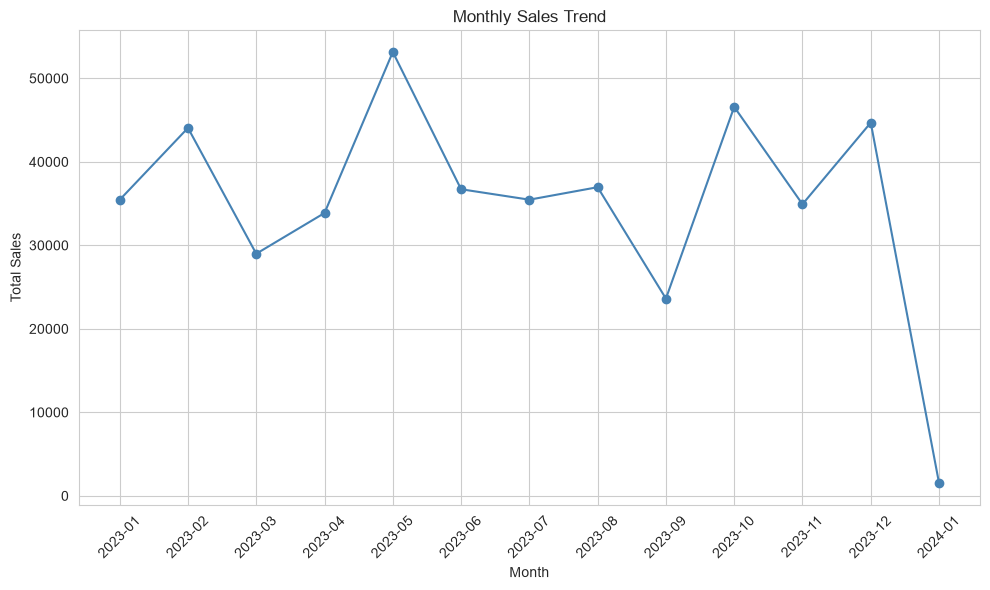

In [8]:
monthly_sales = df.groupby('Month')[col_map['amount']].sum().reset_index()

plt.figure()
plt.plot(monthly_sales['Month'], monthly_sales[col_map['amount']], marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('01_monthly_sales_trend.png', dpi=150)
plt.show()


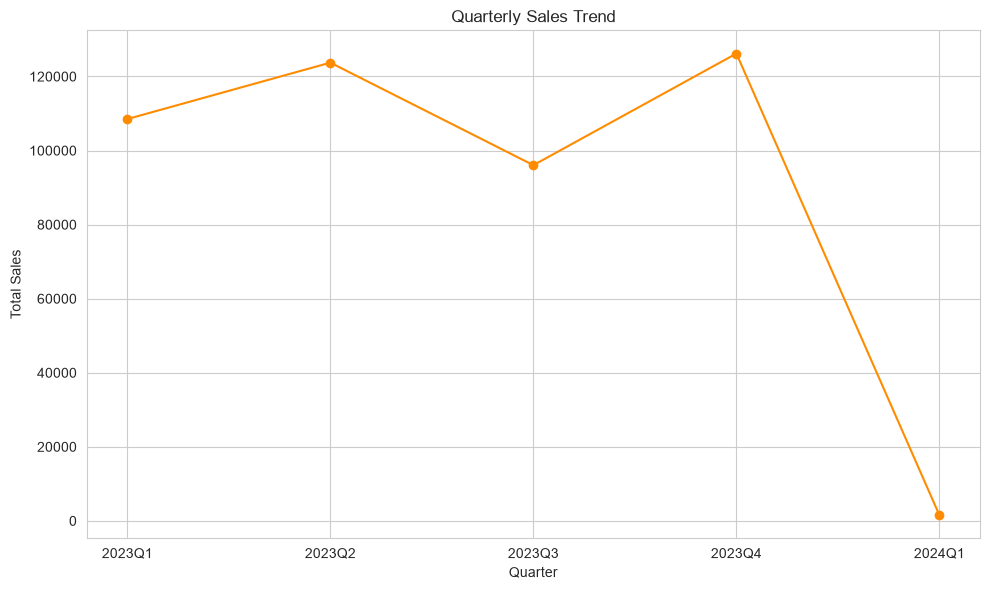

In [9]:
quarterly_sales = df.groupby('Quarter')[col_map['amount']].sum().reset_index()

plt.figure()
plt.plot(quarterly_sales['Quarter'], quarterly_sales[col_map['amount']], marker='o', color='darkorange')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('02_quarterly_sales_trend.png', dpi=150)
plt.show()


**📝 Observation:** Identify the highest and lowest performing months/quarters. Is there a clear seasonal pattern (e.g. a spike around festive/holiday months)? Note it here after running.

## 8. Customer Demographics Analysis
**Checklist:** distribution of customer age groups, gender breakdown


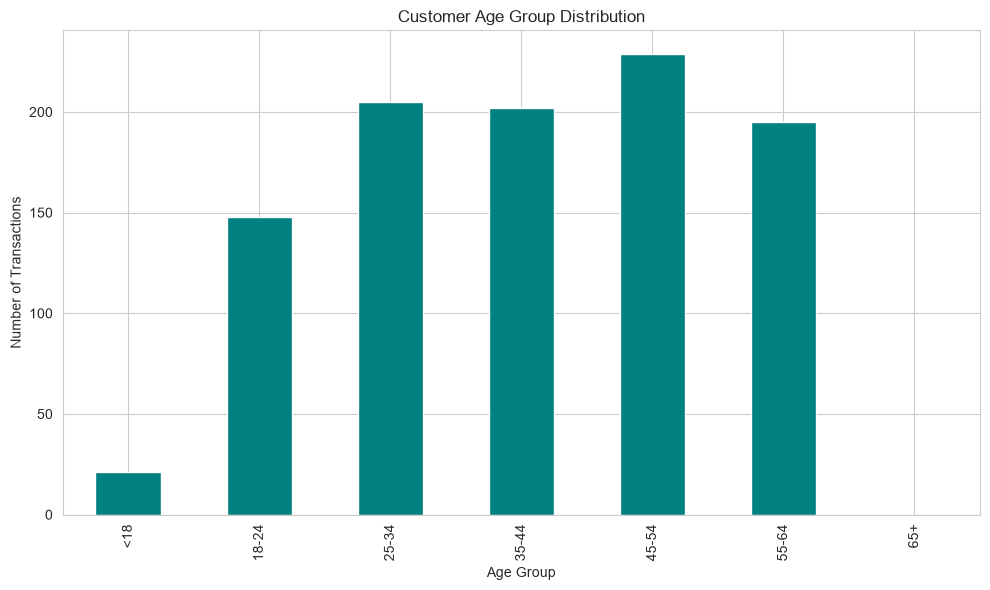

In [10]:
if col_map['age']:
    bins = [0, 18, 25, 35, 45, 55, 65, 120]
    labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
    df['AgeGroup'] = pd.cut(df[col_map['age']], bins=bins, labels=labels)

    plt.figure()
    df['AgeGroup'].value_counts().sort_index().plot(kind='bar', color='teal')
    plt.title('Customer Age Group Distribution')
    plt.xlabel('Age Group')
    plt.ylabel('Number of Transactions')
    plt.tight_layout()
    plt.savefig('03_age_group_distribution.png', dpi=150)
    plt.show()
else:
    print("No Age column detected — skipping age distribution.")


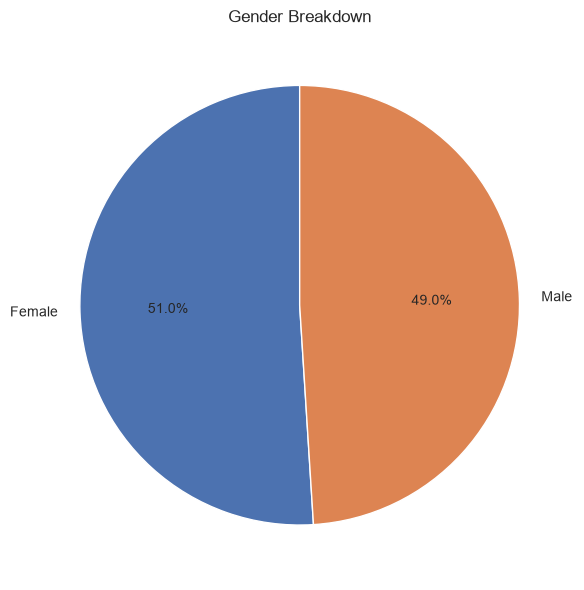

In [11]:
if col_map['gender']:
    plt.figure()
    df[col_map['gender']].value_counts().plot(
        kind='pie', autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#DD8452']
    )
    plt.title('Gender Breakdown')
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig('04_gender_breakdown.png', dpi=150)
    plt.show()
else:
    print("No Gender column detected — skipping gender breakdown.")


**📝 Observation:** Note which age group makes up the largest share of transactions, and whether the gender split is roughly even or skewed toward one group.

## 9. Product Analysis
**Checklist:** top 10 best-selling products; revenue by product category (bar chart)


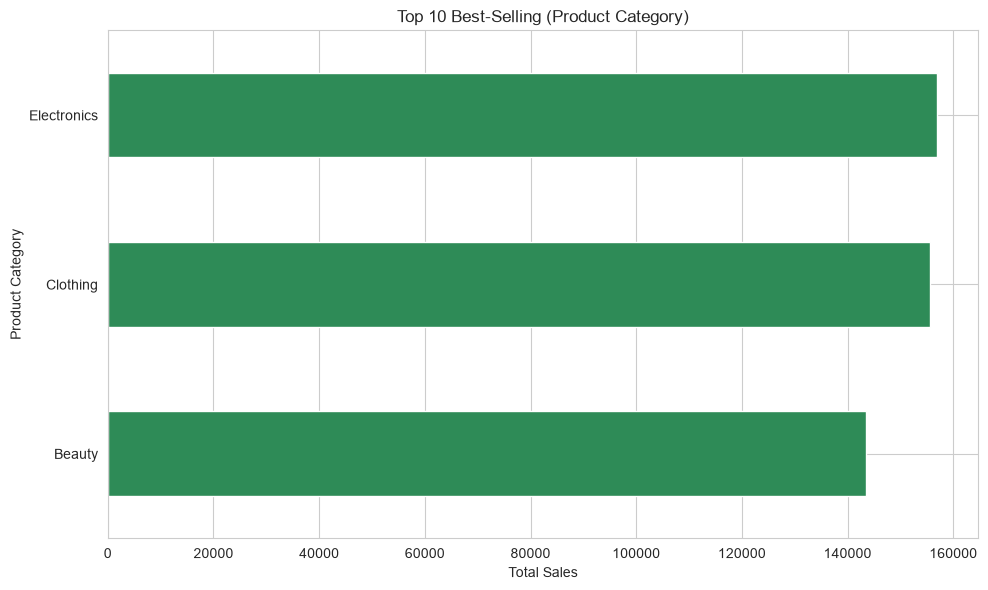

In [12]:
product_col = col_map['product'] or col_map['category']

if product_col:
    top10 = df.groupby(product_col)[col_map['amount']].sum().sort_values(ascending=False).head(10)
    plt.figure()
    top10.plot(kind='barh', color='seagreen')
    plt.title(f'Top 10 Best-Selling ({product_col})')
    plt.xlabel('Total Sales')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('05_top10_products.png', dpi=150)
    plt.show()
else:
    print("No product/category column detected — skipping.")


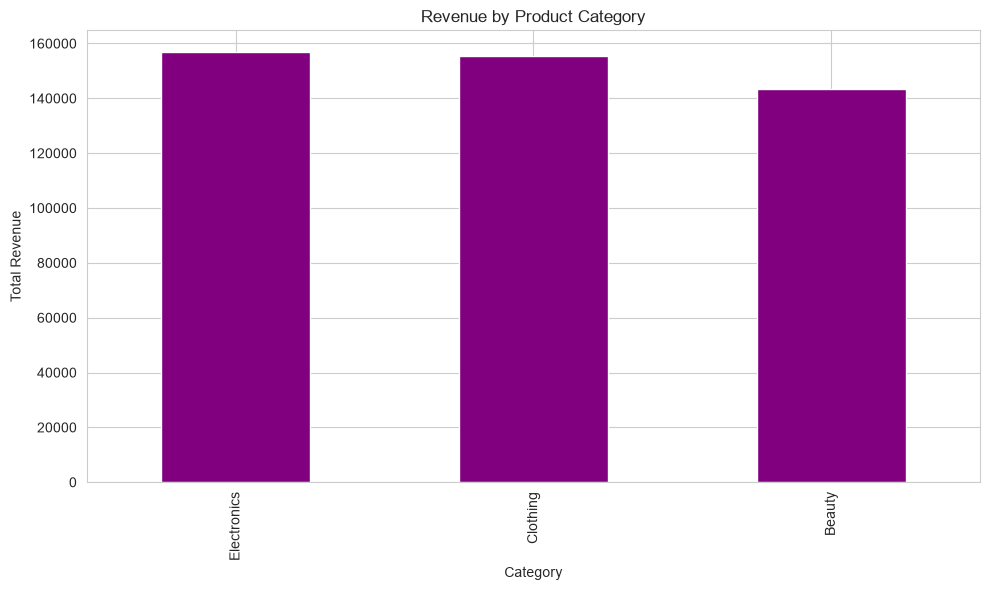

In [13]:
if col_map['category']:
    cat_revenue = df.groupby(col_map['category'])[col_map['amount']].sum().sort_values(ascending=False)
    plt.figure()
    cat_revenue.plot(kind='bar', color='purple')
    plt.title('Revenue by Product Category')
    plt.xlabel('Category')
    plt.ylabel('Total Revenue')
    plt.tight_layout()
    plt.savefig('06_revenue_by_category.png', dpi=150)
    plt.show()
else:
    print("No category column detected — skipping.")


**📝 Observation:** Note which category/product drives the most revenue — this is usually where marketing/inventory focus should go.

## 10. Correlation Heatmap
**Checklist:** correlation matrix between numerical variables


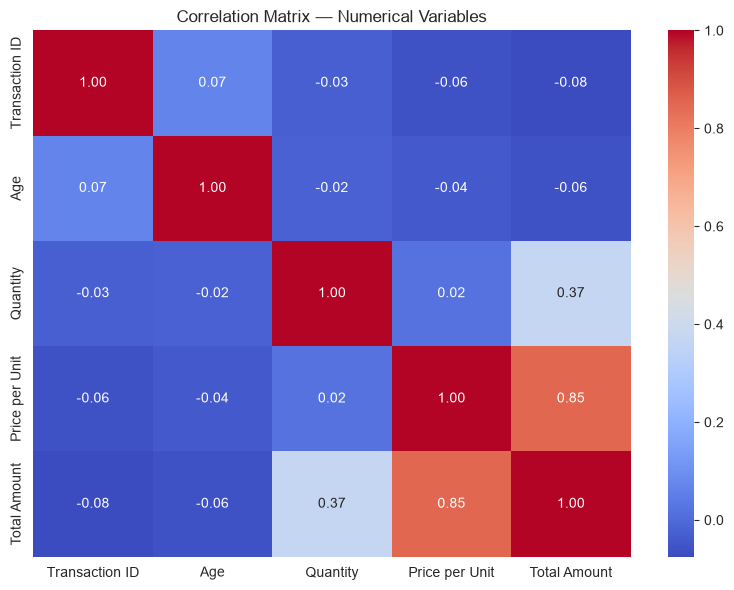

In [14]:
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix — Numerical Variables')
plt.tight_layout()
plt.savefig('07_correlation_heatmap.png', dpi=150)
plt.show()


**📝 Observation:** Look for strong correlations (close to +1 or -1). For example, Quantity and Total Amount are often positively correlated since more units usually means a higher bill.

## 11. Additional Visualisation — Non-Obvious Insight
**Checklist:** at least one additional visualisation of your choice that reveals a non-obvious insight

Here: average spend per transaction by category and gender, to see if buying behaviour differs between groups.


<Figure size 1000x600 with 0 Axes>

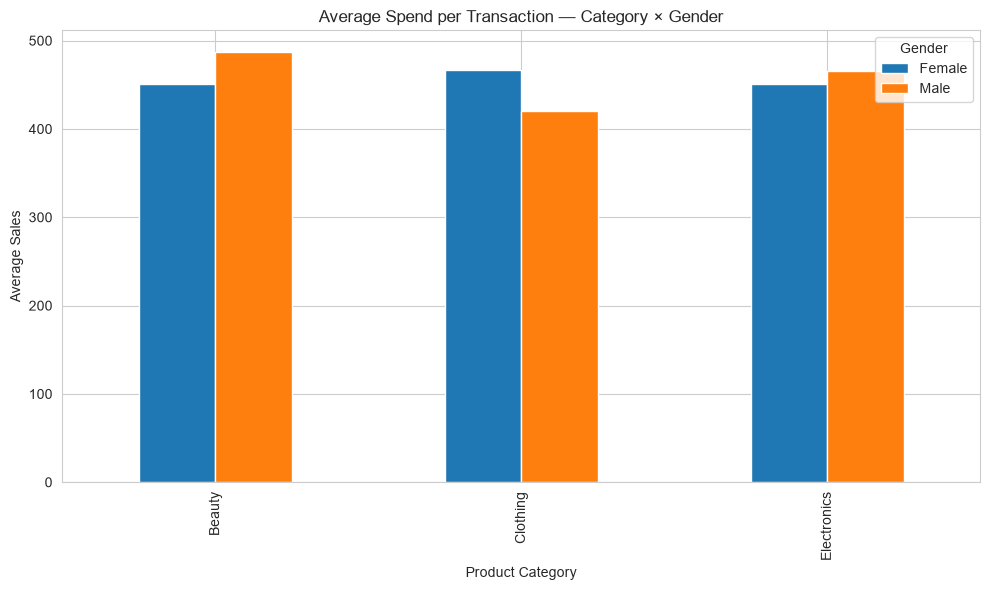

In [15]:
if col_map['gender'] and col_map['category']:
    pivot = df.pivot_table(
        index=col_map['category'], columns=col_map['gender'],
        values=col_map['amount'], aggfunc='mean'
    )
    plt.figure()
    pivot.plot(kind='bar')
    plt.title('Average Spend per Transaction — Category × Gender')
    plt.ylabel('Average Sales')
    plt.tight_layout()
    plt.savefig('08_avg_spend_category_gender.png', dpi=150)
    plt.show()
else:
    print("Gender and/or Category column not available — skipping this extra visualisation.")


**📝 Observation:** Note any category where one gender spends noticeably more per transaction than the other — this could inform targeted promotions.

## 12. Conclusion — Actionable Business Recommendations

*(Fill this in based on YOUR actual chart outputs once you run the notebook — here is the structure to follow, with example phrasing.)*

1. **Seasonal staffing/inventory planning:** Sales peak in [month/quarter from your chart] — increase stock and staffing ahead of that period, and plan promotions to lift the lowest month.
2. **Category investment:** [Top category from your revenue-by-category chart] drives the largest share of revenue — prioritise supplier negotiations and marketing spend here, while testing bundle offers for underperforming categories.
3. **Targeted marketing by demographic:** The [age group] segment accounts for the most transactions — tailor campaigns (channel, messaging, timing) toward this group, while running acquisition campaigns for under-represented age groups.
4. **(Optional) Gender-specific promotions:** If the Category × Gender chart shows a clear gap, consider gender-targeted promotions for the categories with the biggest average-spend difference.

---
### ✅ This notebook has covered every Level 1 · Task 1 checklist item:
- [x] Load dataset + initial inspection (shape, dtypes, nulls)
- [x] Descriptive statistics (mean, median, mode, std)
- [x] Monthly & quarterly time series line charts
- [x] Customer demographics: age group distribution, gender breakdown
- [x] Product analysis: top 10 best-sellers, revenue by category
- [x] Correlation heatmap
- [x] One additional non-obvious insight visualisation
- [x] Markdown observations after each chart
- [x] Conclusion with 3+ actionable business recommendations
